In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [4]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
id2class = {idx: c for c, idx in class2id.items()}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset_concepts, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
dataset_classes = prepare_class_concept_dataset(class_concept_matrix, class2id)

### Train

In [ ]:
from src.BOX.model import BoxHierarchyModel, BoxHierarchyModelJoint
from src.BOX.train import train_box, train_box_joint
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
box_model_joint = BoxHierarchyModelJoint(num_concepts=len(concepts), num_classes=len(classes))
optimizer = Adam(box_model.parameters(), lr=LR)
optimizer_joint = Adam(box_model_joint.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [6]:
train_box(box_model, optimizer, criterion, dataset_concepts, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 3.1764
Epoca [10/100] | Loss: 1.3048
Epoca [20/100] | Loss: 0.1837
Epoca [30/100] | Loss: 0.0230
Epoca [40/100] | Loss: 0.0065
Epoca [50/100] | Loss: 0.0025
Epoca [60/100] | Loss: 0.0013
Epoca [70/100] | Loss: 0.0008
Epoca [80/100] | Loss: 0.0007
Epoca [90/100] | Loss: 0.0005
Epoca [100/100] | Loss: 0.0004

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0014
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


In [8]:
train_box_joint(
    box_model_joint, 
    optimizer_joint, 
    criterion, 
    dataset_concepts, 
    dataset_classes, 
    concept2id, 
    class2id, 
    id2concept,
    id2class
)

Concetti: 50 | Classi: 50
Supervisioni Concetti: 583 | Supervisioni Classi: 2500

Inizio Addestramento Congiunto...
Epoca [1/100] | L_Tot: 10.1080 (L_Conc: 3.1794, L_Cls: 6.9286)
Epoca [10/100] | L_Tot: 8.8672 (L_Conc: 2.9983, L_Cls: 5.8689)
Epoca [20/100] | L_Tot: 3.6841 (L_Conc: 1.3125, L_Cls: 2.3716)
Epoca [30/100] | L_Tot: 3.0191 (L_Conc: 1.0170, L_Cls: 2.0021)
Epoca [40/100] | L_Tot: 2.8202 (L_Conc: 0.9237, L_Cls: 1.8965)
Epoca [50/100] | L_Tot: 2.4087 (L_Conc: 0.7083, L_Cls: 1.7003)
Epoca [60/100] | L_Tot: 1.4311 (L_Conc: 0.3689, L_Cls: 1.0621)
Epoca [70/100] | L_Tot: 0.8830 (L_Conc: 0.1758, L_Cls: 0.7072)
Epoca [80/100] | L_Tot: 0.8166 (L_Conc: 0.1518, L_Cls: 0.6648)
Epoca [90/100] | L_Tot: 0.7855 (L_Conc: 0.1465, L_Cls: 0.6389)
Epoca [100/100] | L_Tot: 0.7712 (L_Conc: 0.1438, L_Cls: 0.6274)

Addestramento completato!

Verifica di alcune assegnazioni Classe-Concetto:
Classe: antelope | Concetto: black
 - P_teorica: 0.0 -> P_predetta: 0.0000
Classe: hamster | Concetto: black
 - P

### Visualization

In [17]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

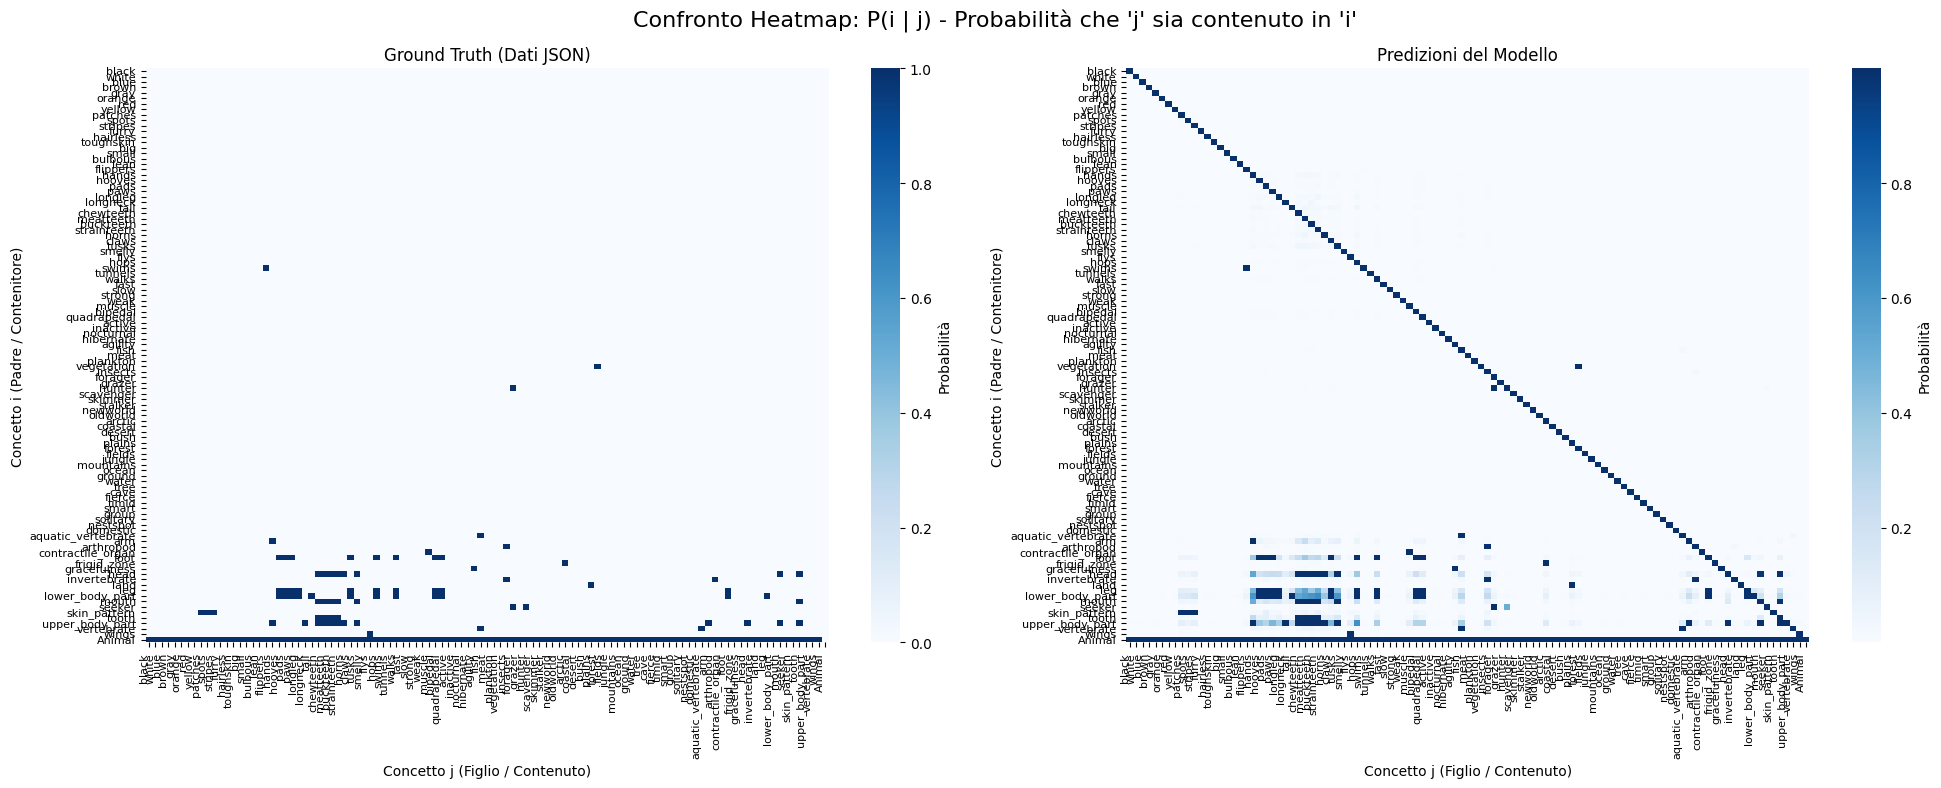

In [ ]:
visualize_heatmap_compare(box_model, dataset_concepts, concept2id, id2concept)

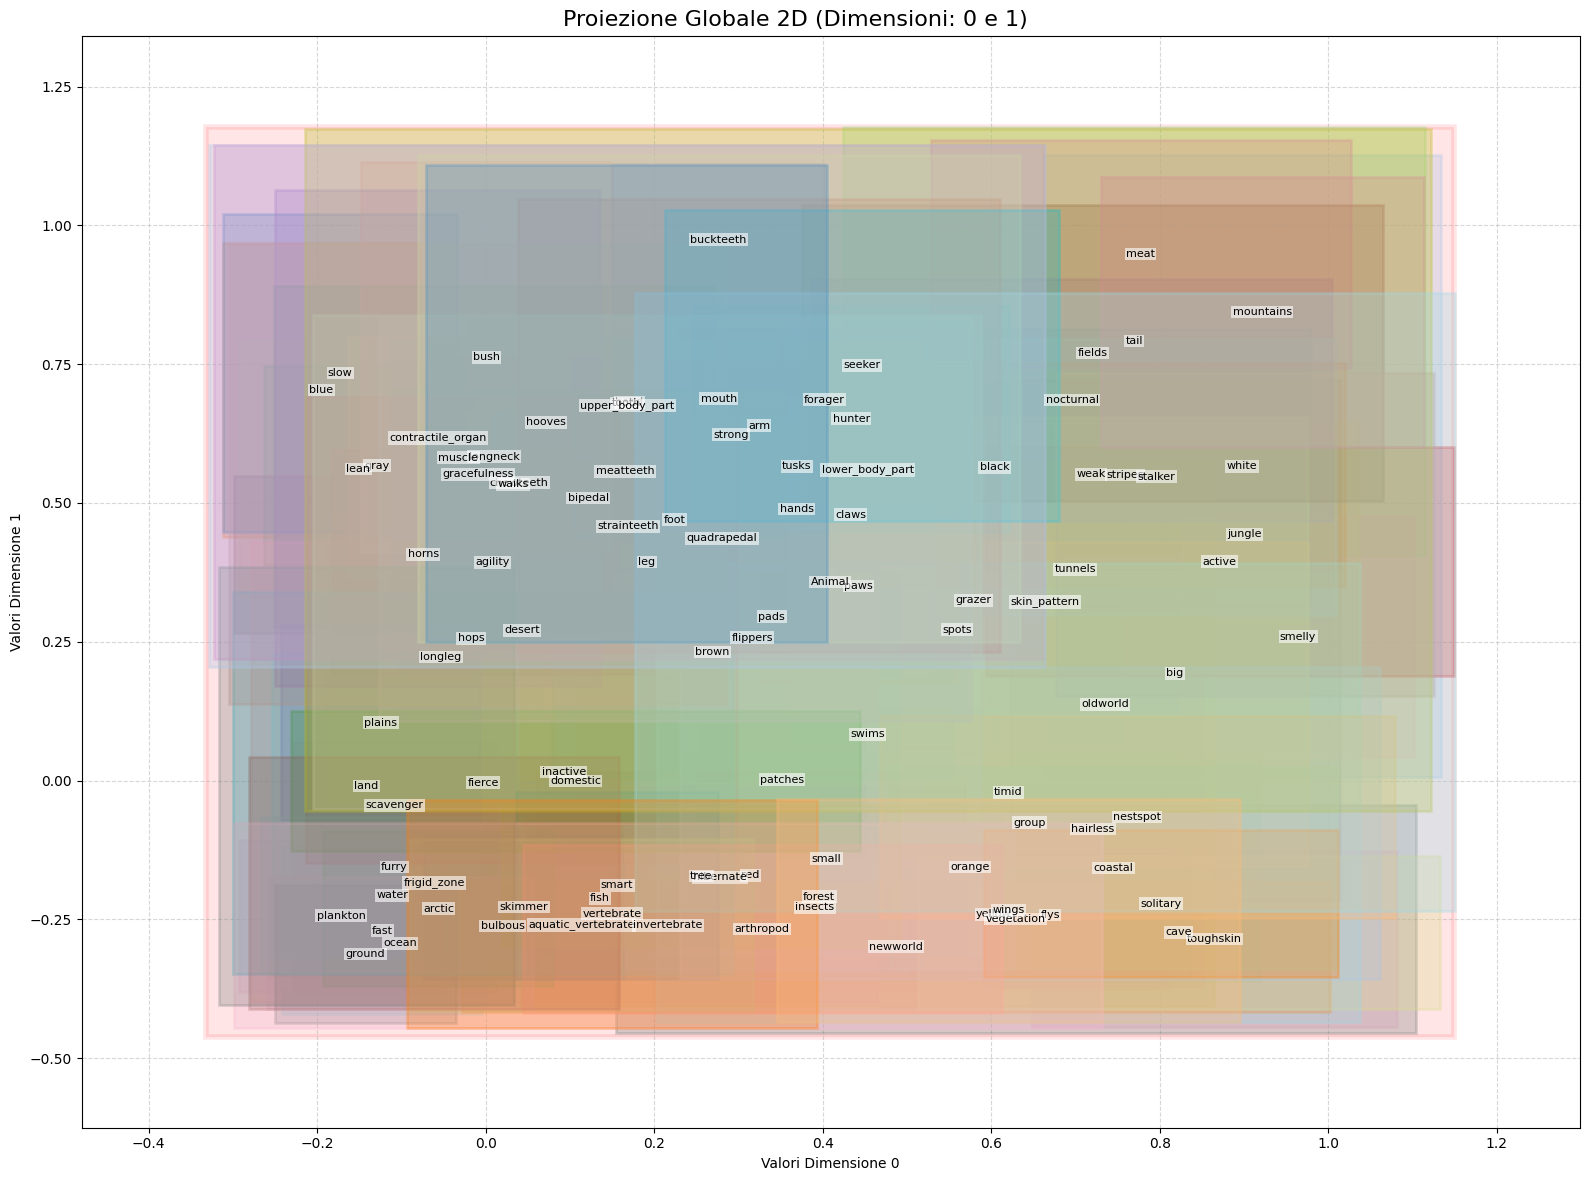

In [19]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

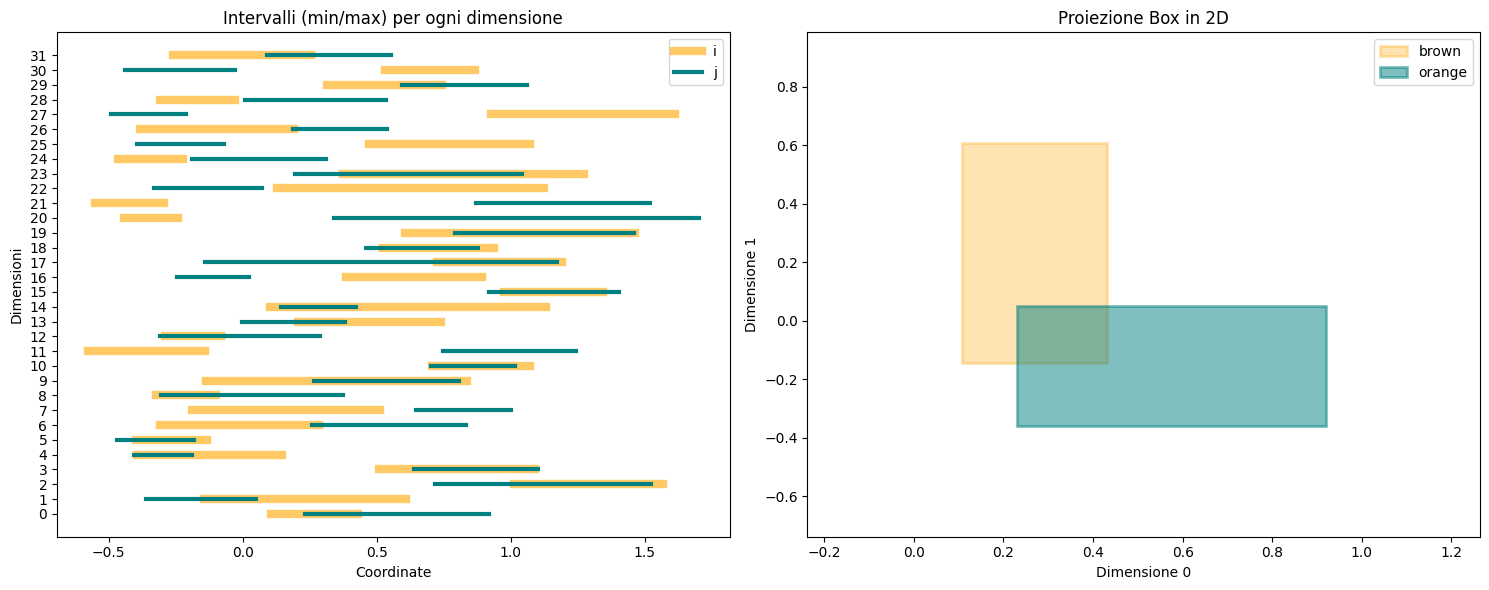

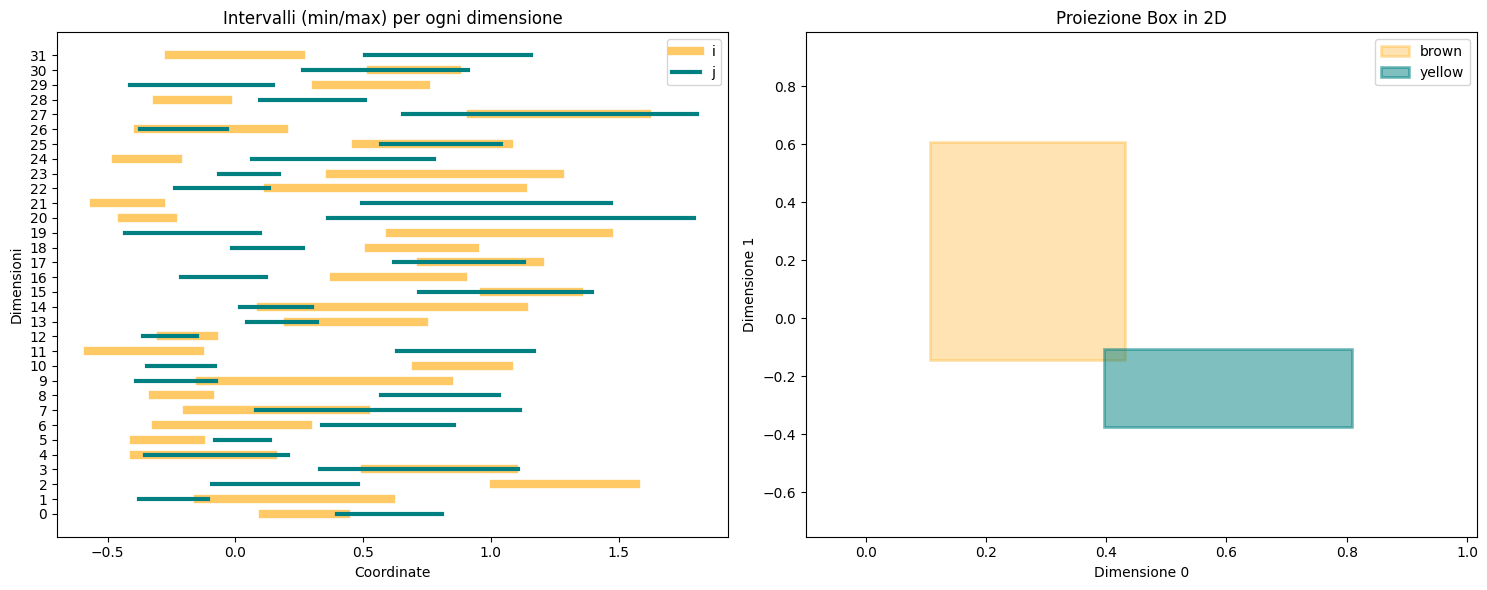

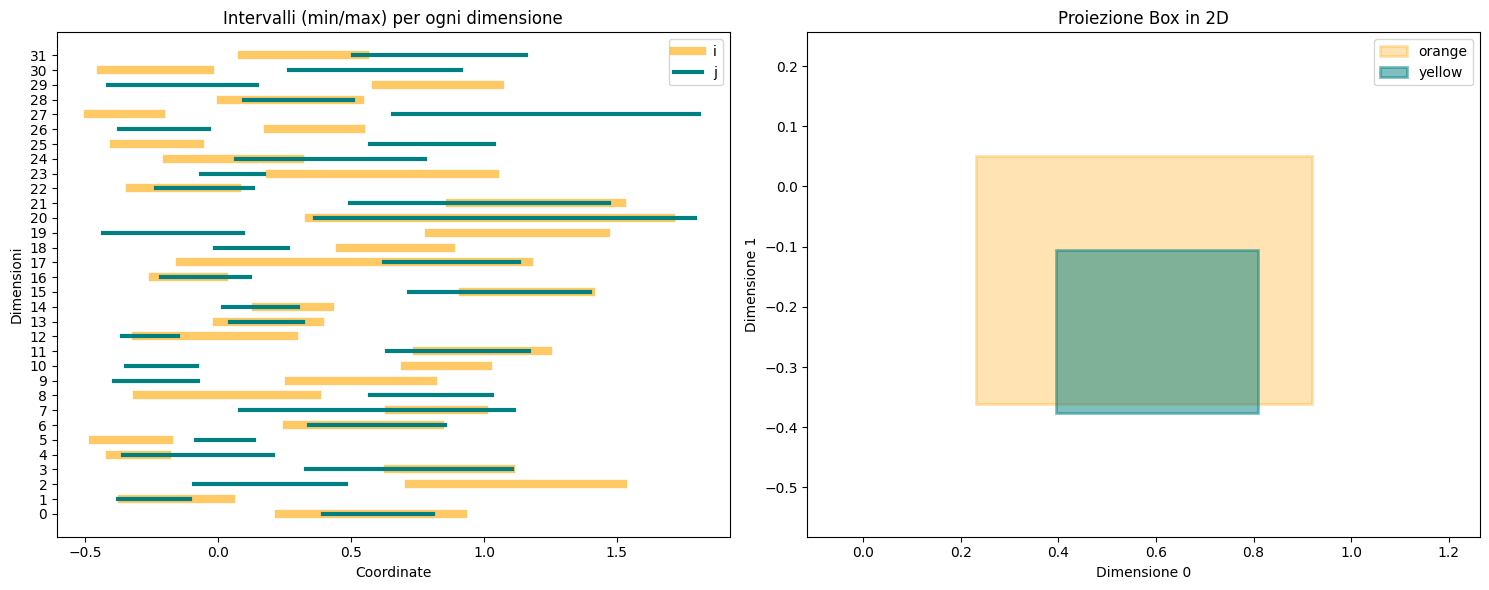

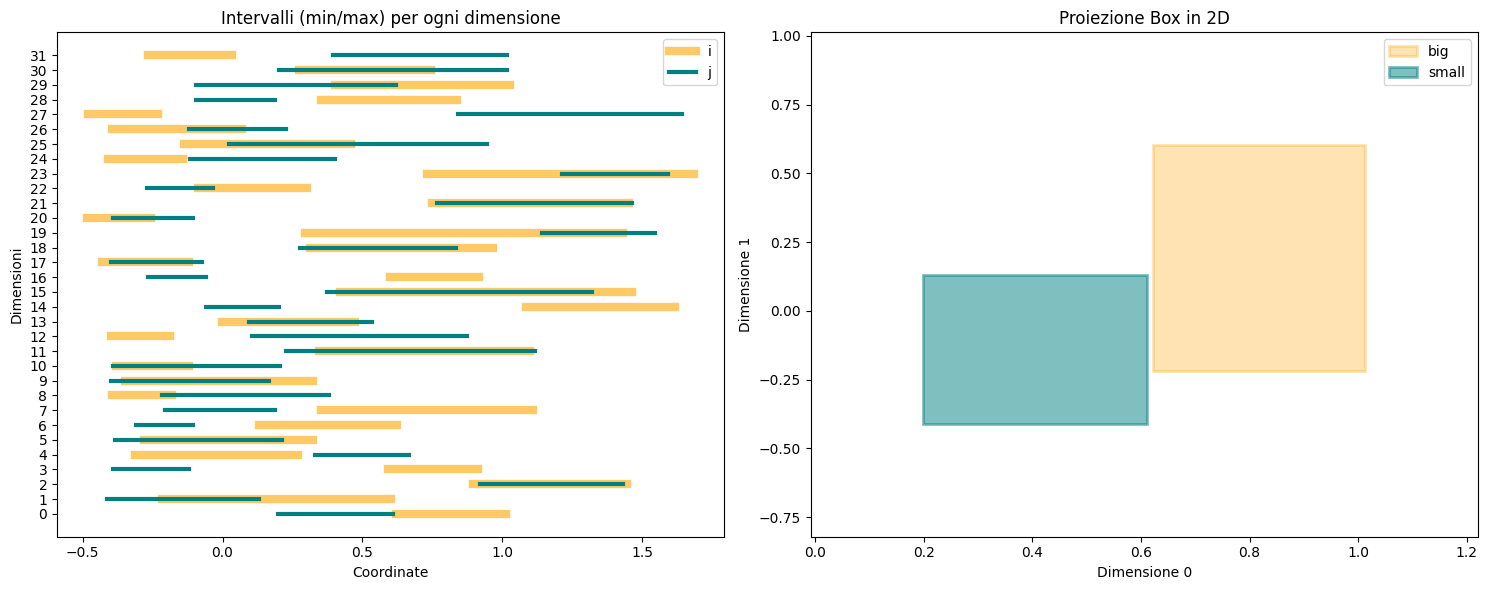

In [20]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [ ]:
import torch
torch.save(box_model.state_dict(), "../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia.pth")
torch.save(box_model_joint.state_dict(), "../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia_joint.pth")